## **Import Library Package**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Baca Dataset**

In [6]:
df = pd.read_csv("../data/dataset-uci.csv")

## **Ringkasan dan Statistik Dataset**

In [7]:
print(f"Jumlah Baris (Pasien): {df.shape[0]}")
print(f"Jumlah Kolom (Fitur): {df.shape[1]}\n")
print("Info struktur data:")
print(df.info())

Jumlah Baris (Pasien): 319
Jumlah Kolom (Fitur): 39

Info struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                         

## **Missing Value dan Duplikat** 

In [8]:
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Total Missing Values: {total_missing}")
if total_missing > 0:
    print(missing_values[missing_values > 0])

duplicate_rows = df.duplicated().sum()
print(f"Jumlah Baris Duplikat: {duplicate_rows}")

Total Missing Values: 0
Jumlah Baris Duplikat: 0


## **Ringkasan Statistik dari Fitur Medis Pilihan**

In [9]:
sample_cols = [
    "Age",
    "Body Mass Index (BMI)",
    "Visceral Fat Rating (VFR)",
    "Total Cholesterol (TC)",
    "Triglyceride",
    "Alanin Aminotransferaz (ALT)",
]
print(df[sample_cols].describe().T)

                              count        mean        std    min     25%  \
Age                           319.0   48.068966  12.114558  20.00   38.50   
Body Mass Index (BMI)         319.0   28.877116   5.313707  17.40   25.25   
Visceral Fat Rating (VFR)     319.0    9.078370   4.332501   1.00    6.00   
Total Cholesterol (TC)        319.0  203.495298  45.758501  60.00  172.00   
Triglyceride                  319.0  144.502163  97.904493   1.39   83.00   
Alanin Aminotransferaz (ALT)  319.0   26.855799  27.884413   3.00   14.25   

                                50%     75%    max  
Age                            49.0   56.00   96.0  
Body Mass Index (BMI)          28.3   31.85   49.7  
Visceral Fat Rating (VFR)       9.0   12.00   31.0  
Total Cholesterol (TC)        198.0  233.00  360.0  
Triglyceride                  119.0  172.00  838.0  
Alanin Aminotransferaz (ALT)   19.0   30.00  372.0  


# **Visualisasi**

## **Distribusi Data Pasien Batu Empedu**

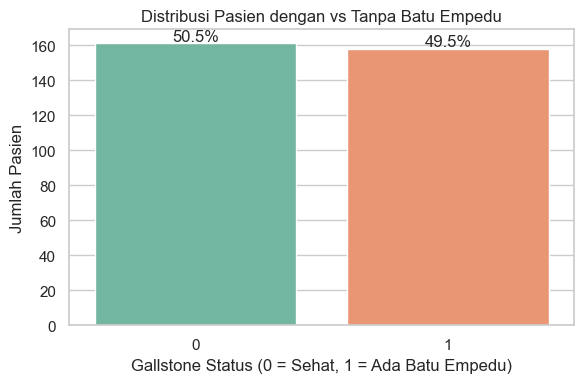

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# --- VISUALISASI 1: Distribusi Kelas Target (Gallstone Status) ---
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Gallstone Status", data=df, palette="Set2")
plt.title("Distribusi Pasien dengan vs Tanpa Batu Empedu")
plt.xlabel("Gallstone Status (0 = Sehat, 1 = Ada Batu Empedu)")
plt.ylabel("Jumlah Pasien")
# Menampilkan persentase di atas bar
for p in ax.patches:
    percentage = f"{100 * p.get_height() / len(df):.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()

## **Korelasi Indikator Obesitas Terhadap Status Batu Empedu**

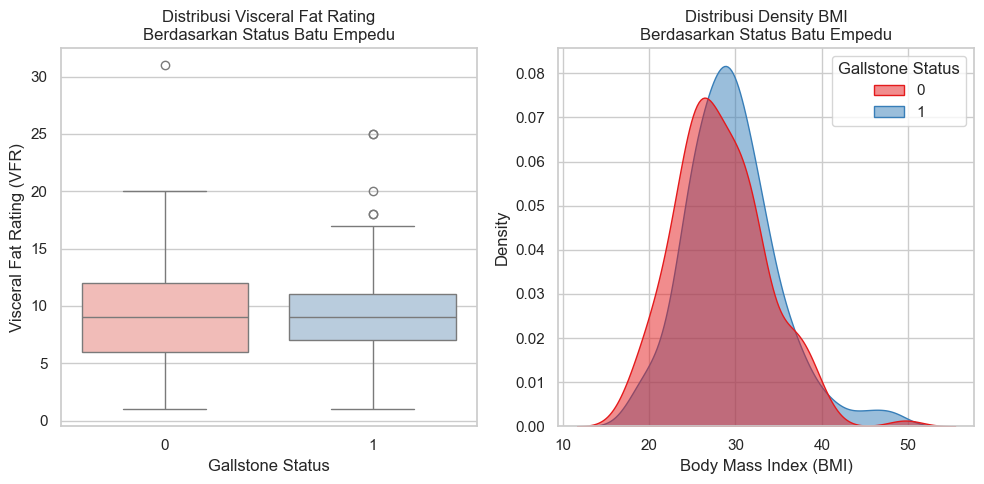

In [14]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    x="Gallstone Status",
    y="Visceral Fat Rating (VFR)",
    data=df,
    palette="Pastel1",
)
plt.title("Distribusi Visceral Fat Rating\nBerdasarkan Status Batu Empedu")

plt.subplot(1, 2, 2)
sns.kdeplot(
    data=df,
    x="Body Mass Index (BMI)",
    hue="Gallstone Status",
    fill=True,
    common_norm=False,
    palette="Set1",
    alpha=0.5,
)
plt.title("Distribusi Density BMI\nBerdasarkan Status Batu Empedu")
plt.tight_layout()
plt.show()

## **Korelasi Profil Lipid terhadap Status Batu Empedu**

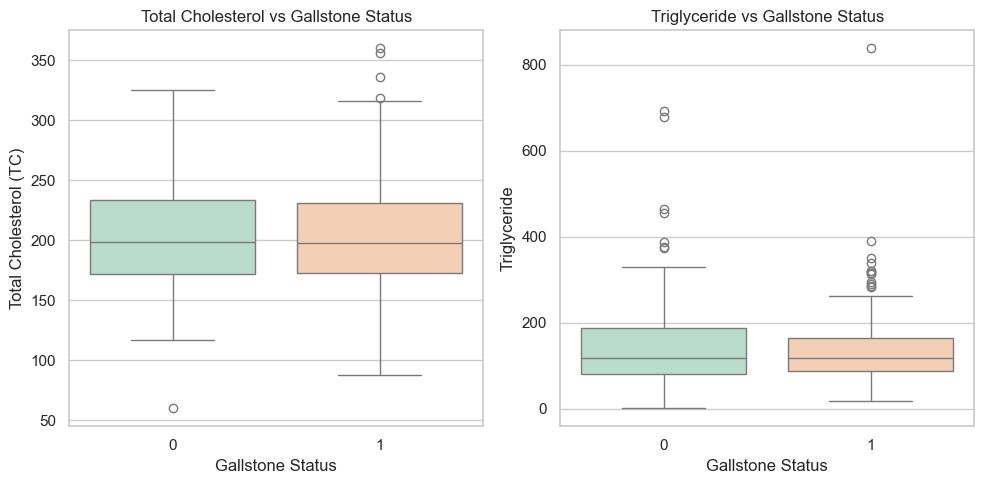

In [12]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    x="Gallstone Status",
    y="Total Cholesterol (TC)",
    data=df,
    palette="Pastel2",
)
plt.title("Total Cholesterol vs Gallstone Status")

plt.subplot(1, 2, 2)
sns.boxplot(x="Gallstone Status", y="Triglyceride", data=df, palette="Pastel2")
plt.title("Triglyceride vs Gallstone Status")
plt.tight_layout()
plt.show()

## **Matriks Korelasi antar-fitur Klinis Utama**

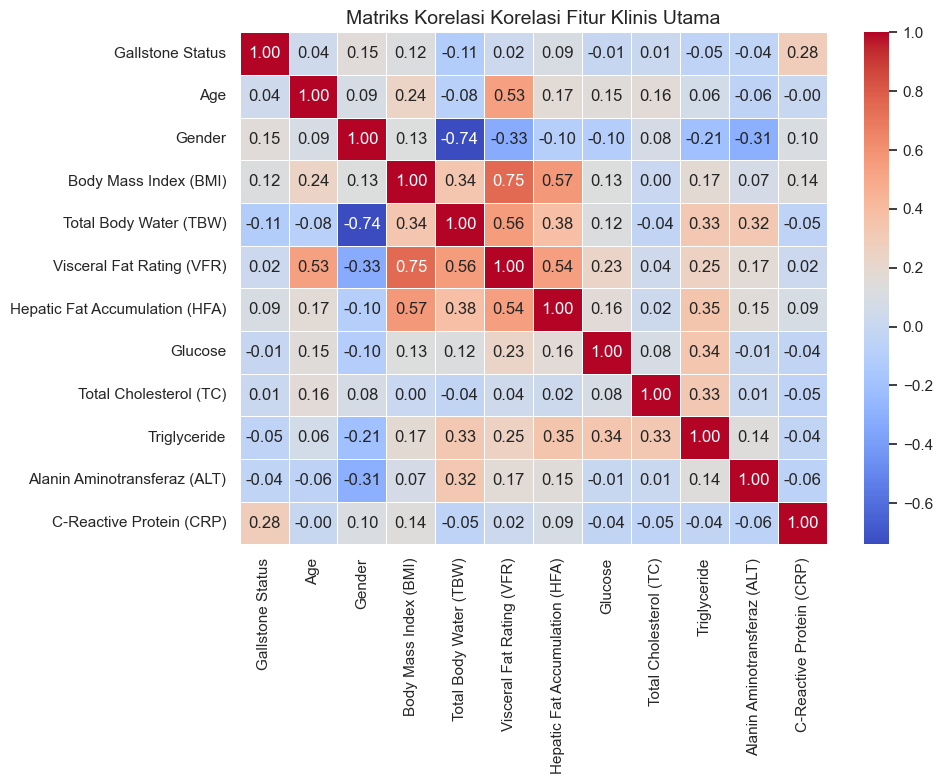

In [13]:
selected_features = [
    "Gallstone Status",
    "Age",
    "Gender",
    "Body Mass Index (BMI)",
    "Total Body Water (TBW)",
    "Visceral Fat Rating (VFR)",
    "Hepatic Fat Accumulation (HFA)",
    "Glucose",
    "Total Cholesterol (TC)",
    "Triglyceride",
    "Alanin Aminotransferaz (ALT)",
    "C-Reactive Protein (CRP)",
]

plt.figure(figsize=(10, 8))
corr_matrix = df[selected_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Korelasi Fitur Klinis Utama", fontsize=14)
plt.tight_layout()
plt.show()